# Indexing & strain refinement of a map of Laue patterns (1/3)

Index Laue spots (hkl Miller indices, grain/phase) and refine the orientation matrix UB and the deviatoric strain of every image of a map, using multiprocessing (1 image per cpu).

Results: `prefix####_g0.fit`, `prefix####_g1.fit`, ... (1 file per grain found in image `####`)

**This notebook is part of the LaueTools package** (https://github.com/BM32ESRF/lauetools)

Author: J.-S. Micha, Last revision: Sept 2026. Tested with python 3.12 (jupyterlab, jupyterhub, VS Code)

| notebook | input | output |
|---|---|---|
| `1_index_refine.ipynb` | `.cor` files (peak search results) | `.fit` files (indexed spots, UB matrix, strain per grain) |
| `2_postprocess_maps.ipynb` | `.fit` files | maps & statistics: nb of spots, pixel deviation, strain, lattice parameters, orientation |
| `3_segmentation_grains.ipynb` | `.fit` files | grains (clusters of orientation), KAM, GROD, boundaries |

**All settings of an experiment are in a YAML configuration file**: copy `config_template.yaml` to `configs/my_experiment.yaml`, edit it and set `CONFIG` in the first code cell. The same file is used by the 3 notebooks. `configs/` contains examples of BM32 datasets (access to ESRF `/data` needed).

Batch mode (optional, no browser): `papermill 1_index_refine.ipynb run_myexp.ipynb -p CONFIG configs/my_experiment.yaml`

# SETTINGS

In [1]:
CONFIG = 'configs/a321220_MgO.yaml'   # configuration file of your experiment

NB_CPUS = None             # None: nb_cpus of the configuration file
RUN_BATCH = True           # False: only tests on 1 image
SAVE_RESULTS = True        # save allresults_<stamp>.pickle (summary of the batch)
OVERWRITE_RESULTS = False  # True: overwrite an existing allresults_<stamp>.pickle
EXECUTION = 'local'        # 'local': batch in this jupyter session; 'slurm': job(s) on the ESRF cluster (section BATCH on SLURM)

# IMPORTS

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"   # before numpy import: 1 thread per process (images are dispatched on cpus)
import time
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    import ipympl  # interactive plots (zoom, hover) in JupyterLab / VS Code
    %matplotlib widget
except ImportError:
    %matplotlib inline

import LaueTools.indexing_batch as IB
import LaueTools.IOLaueTools as IOLT
import LaueTools.generaltools as GT
import LaueTools.dict_LaueTools as DictLT
from LaueTools.LaueDataResultsPlots import PlotPeakPos

print('LaueTools from', Path(IB.__file__).parent)
print(f'nb of cpus available: {os.cpu_count()}')

loading lauetools_config.json in  /mnt/multipath-shares/data/bm32/inhouse/SOFT/lauetoolsDEV/lauetools/LaueTools
No user materials.yaml found. Using default materials.yaml
-- warning: sklearn.metrics is not installed. For matchingrate.py module, it could be useful... but not necessary
-- WARNING: module Image or PIL is not installed, but only used for templateimagematching
loading readmccd.py
-- WARNING: Missing library libtiff, Please install: pylibtiff if you need open some tiff images. However, Fabio or PIL can do the job!
hostname = hpc6-03
LaueTools from /mnt/multipath-shares/data/bm32/inhouse/SOFT/lauetoolsDEV/lauetools/LaueTools
nb of cpus available: 64


# LOAD CONFIGURATION

After editing the configuration file, run this cell again.

In [3]:
cfg = IB.load_config(CONFIG)
IB.print_config(cfg)
config_ok = IB.check_config(cfg)

scan = cfg['scan']
mapdims, invmapdims = scan['mapdims'], scan['invmapdims']   # (fast, slow), (slow, fast)
fit_folder = cfg['output']['fit_folder']
fit_folder = '/data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/fitfiles_MgO_3grains'
key_material = cfg['material']['key_material']

---- a321220 MgO ----  (/gpfs/jazzy/data/bm32/inhouse/SOFT/lauetoolsDEV/lauetools/LaueTools/notebooks/indexation/configs/a321220_MgO.yaml)
.cor files:  /data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/corfiles/eiger4m_####.cor
.fit files:  /data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/fitfiles_MgO
map:         mapdims (fast, slow) = (51, 51), motors (yech, xech)
detector:    EIGER_4MCdTe, calibration /data/visitor/a321220/bm32/20260915/RAW_DATA/MH73/MH73_Ge/scan0001/calibGe001_MH73_RT_mardi.det
material:    MgO, energy 5-22 keV (indexing up to 19 keV), nbGrainstoFind = 3
2601 .cor files found in /data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/corfiles
Configuration OK


## [OPTION] scans of the experiment from the BLISS hdf5 file

to find the `dmesh` command of the map and set `mapdims` = [nbsteps motor1 + 1, nbsteps motor2 + 1] in the configuration file

In [4]:
if scan['hdf5_logfile'] is not None and Path(scan['hdf5_logfile']).exists():
    import pandas as pd
    import LaueTools.logfile_reader as iohdf5
    listscans, listcts = iohdf5.get_scans_cts(str(scan['hdf5_logfile']))
    dfallscans = pd.DataFrame(listscans, columns=['start_time', 'end_time', 'sample_dataset_scanindex', 'fullcommand',
                                                  'scanindex', 'scantype', 'motors', 'localhdf5file', 'imagefolder'])
    print(f'{len(listscans)} scans and {len(listcts)} saved count commands found')
    display(dfallscans[dfallscans['scantype'].astype(str).str.contains('mesh')][['start_time', 'sample_dataset_scanindex', 'fullcommand']])
else:
    print('no hdf5 log file (scan: hdf5_logfile in the configuration file)')

no hdf5 log file (scan: hdf5_logfile in the configuration file)


## Material

`key_material` must be a key of the LaueTools dictionary of materials, or of `mymaterials` in the configuration file:

```yaml
material:
  key_material: MyPhase
  mymaterials:
    MyPhase: [MyPhase, [4.4, 5.3, 3.8, 90, 88, 90], 'no']   # key, lattice parameters, extinction rules
```

In [5]:
mymaterials = cfg['material']['mymaterials']
if mymaterials and key_material in mymaterials:
    print('own material:', mymaterials[key_material])
else:
    print('LaueTools material:', DictLT.dict_Materials.get(key_material))

searchedstring = key_material[:2]   # list materials of the LaueTools dict containing this string
print(f'\n------- materials containing "{searchedstring}" -------')
print('\n'.join(f'{key}: {val}' for key, val in DictLT.dict_Materials.items() if searchedstring in key))

LaueTools material: ['MgO', [4.211, 4.211, 4.211, 90, 90, 90], 'fcc']

------- materials containing "Mg" -------
Mg: ['Mg', [3.2095, 3.2095, 5.2104, 90, 90, 120], 'no']
MgFe2O4: ['MgFe2O4', [8.35, 8.35, 8.35, 90, 90, 90], 'SG227']
MgO: ['MgO', [4.211, 4.211, 4.211, 90, 90, 90], 'fcc']
MgO_double: ['MgO_double', [8.422, 8.422, 8.422, 90, 90, 90], 'fcc']


# TEST on 1 image

Tune the indexing parameters (section `indexing` of the configuration file) on a few images before the batch. Here the internal multiprocessing of indexing is used (all cpus on 1 image).

Parameters can also be changed here for tests (then copy the good ones in the configuration file):
`params_test.dict_indexrefine['central spots indices'] = [0, 1, 2]`, `params_test.nbGrainstoFind = 1`, ... (call `params_test.build_LUT()` after changing `nlutmax`)

Previous orientations can be tested first: `params_test.usepreviousUB = [np.array(UB)]` (`skipindexing = True`: only refine them)

In [6]:
params_test.fit_folder

NameError: name 'params_test' is not defined

In [ ]:
imageindex = cfg['run']['test_image_index']
filename = IB.corfile_path(cfg, imageindex)

params_test = IB.params_from_config(cfg, useinternalmultiprocessing=False, outputlistindices=True,
                                    ignorefitfileresults=True, verboselevel=1)


params_test.dict_indexrefine['central spots indices'] = np.arange(20).tolist()
params_test.nbGrainstoFind = 4
params_test.dict_indexrefine['NBMAXPROBED'] = 21
params_test.fit_folder = '/data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/fitfiles_MgO_4grains'

t0 = time.time()
res = IB.index_refine(filename, params_test)
IB.print_result(res)
print(f'elapsed time {time.time() - t0:.1f} s. .fit files written in {params_test.fit_folder}')

## PLOT experimental and indexed spots (red stars) of grain 0

In [ ]:
spotsindexed = res[4] if len(res) > 4 else []
fig, ax = PlotPeakPos(str(filename), frame='pixel', showindex=False)   # showindex=True: show experimental spot index
if ax:
    ax.grid()
    ax.set_title(f'{filename.parent}\n{filename.name}', fontsize=8)
    if len(spotsindexed):
        XYindexed = IOLT.readfile_cor(str(filename))[0][spotsindexed, 2:4]
        ax.scatter(XYindexed[:, 0], XYindexed[:, 1], marker='*', s=30, alpha=0.5, c='r')

## [OPTION] test on a few successive images

In [10]:
TEST_SEVERAL = False
if TEST_SEVERAL:
    params_test.outputlistindices = False
    params_test.verboselevel = 0
    for imageindex in range(imageindex, imageindex + 4):
        print(f'---------- image {imageindex} ----------')
        IB.print_result(IB.index_refine(IB.corfile_path(cfg, imageindex), params_test))

## [OPTION] remove spots (e.g. substrate) from .cor files

- `IB.removespots_fromfile(blacklistfile, corfile)`: remove the spots (within `dist_tolerance` pixel) present in another .cor file (e.g. substrate only)
- `IB.removespots_fromlist(listindices, corfile)`: remove spots by index (e.g. already indexed spots)
- `IB.merge_corfiles(corfile1, corfile2, outputname, outputfolder)`: concatenate the spots of 2 files

The new .cor file is written in the folder of `corfile` (name prefixed by `p`). For the batch: `params.blacklistfile = blacklistfile` removes the blacklisted spots of every image before indexing.

In [11]:
REMOVE_SPOTS = False
if REMOVE_SPOTS:
    blacklistfile = IB.corfile_path(cfg, 6)          # e.g. image with substrate spots only
    written = IB.removespots_fromfile(blacklistfile, filename, dist_tolerance=2, CCDLabel=scan['CCDLabel'])
    print('purged file written:', filename.parent / written)

# BATCH: INDEX & REFINE all .cor files (multiprocessing)

- set of files: section `selection` of the configuration file (all files, `image_range` or `roi`)
- `run: ignorefitfileresults: false` analyses only images without `_g0.fit` file (e.g. to resume an interrupted batch)
- `run: usepreviousUB: fromfitfile` refines the UB matrix of existing .fit files (e.g. with other `e_max` or tolerances)
- `EXECUTION = 'slurm'` (SETTINGS): the batch runs as a job on the ESRF cluster, see next section (the cell below then only prepares `listfiles` and `params`)

In [4]:
params = IB.params_from_config(cfg)
params.dict_indexrefine['central spots indices'] = np.arange(20).tolist()
params.nbGrainstoFind = 10
params.dict_indexrefine['NBMAXPROBED'] = 31
params.fit_folder = '/data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/fitfiles_MgO_36rains_local'

listfiles = IB.select_corfiles(cfg)
print(f'{len(listfiles)} .cor files to analyse, from {Path(listfiles[0]).name} to {Path(listfiles[-1]).name}')
print(f'map {mapdims[0]} x {mapdims[1]} = {mapdims[0] * mapdims[1]} images')


2601 .cor files to analyse, from eiger4m_0000.cor to eiger4m_2600.cor
map 51 x 51 = 2601 images


## [OPTION] BATCH on LOCAL machine

With EXECUTION = 'local' in SETTINGS, the batch runs on a current machine


In [ ]:
nb_cpus = NB_CPUS or cfg['run']['nb_cpus']
print(f'{nb_cpus} max cpus are available (but not all of them will work in interactive notebook)')

allresults = None
if RUN_BATCH and config_ok and  == 'local':
    allresults = IB.run_multiprocessing(listfiles, params, nb_cpus=nb_cpus)
    GT.printgreen('Done!')

## [OPTION] BATCH on SLURM (ESRF cluster)

With `EXECUTION = 'slurm'` in SETTINGS, the batch runs as a job on a node of the cluster (1 node, 1 process per cpu), not in this jupyter session. The job uses **exactly** `params` and `listfiles` of the cell above, including the changes made in the notebook.

1. **prepare**: writes a job folder `slurm_jobs/<job name>_<date>/` next to the folder of .fit files (`params.fit_folder`) with the parameters (`job_params.pickle`, readable copy `job_params.txt`) and the slurm script `job.slurm`. Logs (`logs/`) and results (`allresults_part###.pickle`) of the job are written there too
2. **submit**: `SUBMIT = True` (sbatch from this notebook, in a jupyter-slurm session), or copy the printed `sbatch ...` command in a terminal of jupyter-slurm
3. **monitor**: state of the job, progress and last lines of the log (run the cell again)
4. **load results**, then SUMMARY and SAVE below, as for a local batch

| `SLURM_MACHINE` | partition | cpus / node |
|---|---|---|
| `magnifix` | magnifix | 192 (priority) 1/3|
| `magnifix2` | magnifix | 2*192 (priority) two nodes 2/3|
| `magnifix3` | magnifix | 3*192 (priority) three nodes 3/3|
| `hpc6`, `hpc7`, `hpc8` | nice (+ constraint) | 96 |
| `auto` | magnifix if more than 96 cpus are asked and a magnifix node has enough idle cpus, otherwise the hpc6/7/8 node with most idle cpus (96 cpus) | |

(partitions, constraints and cpus: `IB.SLURM_MACHINES`, check with `sinfo -N -o "%N %P %c %m %f %T"`)

- time limit: estimate it with a short local benchmark (below). If the job is stopped by the time limit, prepare and submit again with `params.ignorefitfileresults = False`: only images without `_g0.fit` file are analysed
- large maps: `NCHUNKS` > 1 splits the files into `NCHUNKS` jobs (slurm job array), which may run at the same time on several nodes

In [15]:
# # [OPTION] time limit estimate from a short local batch (writes the .fit files of these images)
# BENCHMARK = False
# SLURM_CPUS = 64       # cpus per job (1 node): more than 96 -> magnifix
# NCHUNKS = 1            # nb of jobs (job array), each one on 1/NCHUNKS of listfiles

# if BENCHMARK:
#     sec_cpu_per_image = IB.benchmark(listfiles, params, nb_images=2 * IB.available_cpus())
#     print('suggested time limit:', IB.walltime_estimate(len(listfiles) / NCHUNKS, SLURM_CPUS, sec_cpu_per_image))

  0%|          | 0/128 [00:00<?, ?it/s]

It took 0 min 51 s to index 128 images with 64 cpus.
25.8 s x cpu per image
suggested time limit: 00:34:57


In [5]:
SLURM_MACHINE = 'magnifix3'       # 'auto', 'magnifix3', 'hpc6', 'hpc7', 'hpc8', 'nice'
SLURM_TIME = '0:45:00'      # time limit hh:mm:ss
SLURM_MEM_PER_CPU = '2100M'  # memory per cpu
SLURM_CPUS = 192       # cpus per job (1 node): more than 96 -> magnifix
NCHUNKS = 1            # nb of jobs (job array), each one on 1/NCHUNKS of listfiles
SUBMIT = True               # True: sbatch now (jupyter-slurm session). False: only prepare and print the sbatch command

EXECUTION = 'slurm'

params.fit_folder = '/data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/fitfiles_MgO_10grains_magnifix3'


job = None
if EXECUTION == 'slurm' and config_ok:
    if SLURM_MACHINE == 'auto':
        machine, ncpus = IB.choose_slurm_machine(SLURM_CPUS)
    else:
        machine, ncpus = SLURM_MACHINE, SLURM_CPUS
    job = IB.prepare_slurm_job(cfg, params, listfiles, machine=machine, nb_cpus=ncpus, time=SLURM_TIME,
                               mem_per_cpu=SLURM_MEM_PER_CPU, nchunks=NCHUNKS)
    if SUBMIT:
        IB.submit_slurm_job(job)

job folder: /gpfs/gd/data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/slurm_jobs/laue_MgO_20260929_150122
2601 .cor files, 3 job(s) of 192 cpus on magnifix3, time limit 0:45:00
.fit files -> /data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/fitfiles_MgO_10grains_magnifix3
to submit from a terminal (jupyter-slurm):
    sbatch /gpfs/gd/data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/slurm_jobs/laue_MgO_20260929_150122/job.slurm
Submitted batch job 36934684


In [8]:
# job state, progress and last lines of the log(s): run again to update
# after a restart of the kernel: job = '<job folder>'
if EXECUTION == 'slurm' and job is not None:
    IB.slurm_job_status(job)

job 36934684:
36934684_2 magnifix RUNNING 3:29/45:00 192 cpus frcrg-hpc8-03
36934684_1 magnifix RUNNING 3:29/45:00 192 cpus frcrg-hpc8-02
1/3 result file(s) written
laue_MgO_36934684_0.out: 867/867 images (100%)
    allresults saved at 2026-09-29 15:04:16 in
    /gpfs/gd/data/visitor/a321220/bm32/20260915/PROCESSED_DATA/MH73_HT/MH73_HT_map_2D_p7_MgO_Fe_800/scan0001/slurm_jobs/laue_MgO_20260929_150122/allresults_part000.pickle
    end Tue Sep 29 03:04:16 PM CEST 2026
laue_MgO_36934684_1.out: 613/867 images (71%)
     71%|███████   | 613/867 [03:20<01:10,  3.58it/s]
laue_MgO_36934684_2.out: 548/867 images (63%)
     63%|██████▎   | 548/867 [03:20<01:33,  3.43it/s]


In [23]:
# when the job(s) are finished: results for SUMMARY and SAVE below
if EXECUTION == 'slurm' and job is not None:
    allresults = IB.load_slurm_results(job)

2601 results / 2601 .cor files


## SUMMARY of the batch

quick look at the first indexed grain (g0) of each image. Detailed maps (strain, orientation ...): notebook `2_postprocess_maps.ipynb`

In [28]:
fig.clear('all')

nb of treated datasets : 2601
number of non indexed datasets 0
number of indexed (or updated) datasets 2601


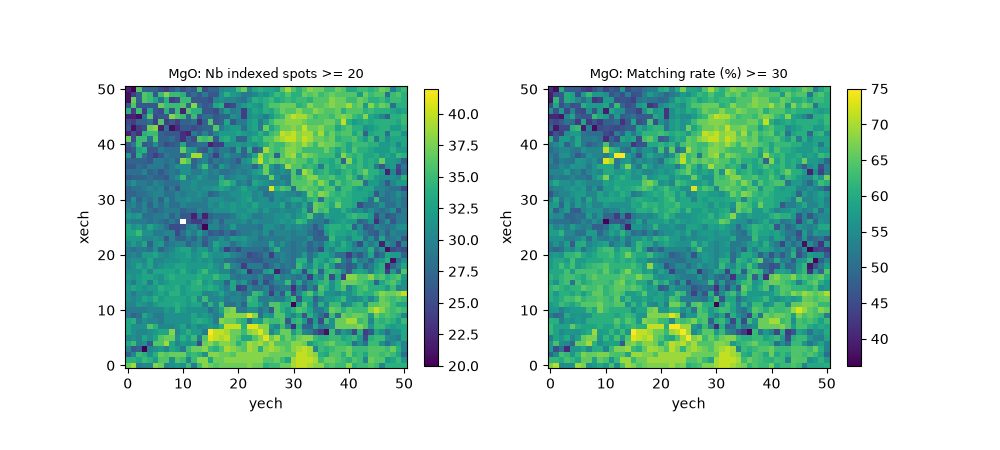

In [29]:
if allresults is None:
    raise RuntimeError('no batch results: set RUN_BATCH = True (and check the configuration)')
summary = IB.summarize_results(allresults, mapdims)

MinNbthreshold = cfg['postprocess']['MinimumNbIndexedSpots']   # minimum nb of indexed spots
MinMRthreshold = 30                                            # minimum matching rate (%)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, key, threshold, title in zip(axes, ('Nbindexedimages2D', 'MRindexedimages2D'), (MinNbthreshold, MinMRthreshold),
                                     (f'Nb indexed spots >= {MinNbthreshold}', f'Matching rate (%) >= {MinMRthreshold}')):
    data = summary[key]
    im = ax.imshow(np.ma.masked_where(~(data >= threshold), data), origin='lower')
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'{key_material}: {title}', fontsize=9)
    ax.set_xlabel(scan['fast_motor'])
    ax.set_ylabel(scan['slow_motor'])
    ax.format_coord = lambda x, y: GT.format_getimageindex_imshow(x, y, invmapdims)

plt.show()


## SAVE results

`allresults_<stamp>.pickle` in `output: results_folder` (default: fit_folder). Reload it with `dictresults = IB.load_allresults(path)`

In [ ]:
if SAVE_RESULTS and allresults is not None:
    IB.save_allresults(cfg, params, allresults, summary, overwrite=OVERWRITE_RESULTS, nb_cpus=nb_cpus)

**Next step:** `2_postprocess_maps.ipynb` with the same `CONFIG`